### DiNoS Demo

Some simple demonstrations with DiNoS (text format overview below)

![img](DiNoS_format.png)

#### Setup & loading

In [3]:
import sys
sys.path.append('code/')
import json
from loader import DINOS

# Load config file
config = json.load(open('config.json'))

In [5]:
# load the dinos json files with the custom loader class
# this handles a lot of parsing, formatting, and computation
gsd = DINOS(config['GSD']['dinos']) # 3s
hdt = DINOS(config['HDT']['dinos']) # 15s

Load data from data/GSD_DiNoS.json...
Load data from data/HDT_DiNoS.json...


### Assorted examples

Some examples of what the DiNoS loader stores and computes, as well as how to fetch the values. Generally, the structure is somewhat recursive (examine the `DINOS` class in `code/loader.py` and the attribues of the contained classes) – so distributions you find at the corpus level are likely also computed on the lemma & word form level.

**`Note`**
There's always the option to call upon .all to display the entire nested dict structure as parsed from the json file.

In [6]:
# showing the very first item here

list(gsd.all.items())[0]

('10000m',
 {'count': 1,
  'forms': {'10000m': {'count': 1,
    'spec_types': {'det_art_specs': {'count': 0, 'spec_id': {}},
     'gen_det_specs': {'count': 0, 'spec_id': {}},
     'other': {'count': 1,
      'spec_id': {"(('ADP-APPR', ('Gender;_', 'Case;_', 'Number;_')),)": 1}}},
    'feat_types': {"('Gender;Masc', 'Case;Acc', 'Number;Sing')": 1},
    'deprel_types': {"('obl', ('Case;Acc', 'Number;Sing'))": 1}}},
  'gender': 'Masc'})

## Macro level (corpus)

In [7]:
# number of NPs
gsd._count

49416

In [8]:
# first 10 lemmas (alphabetically)
list(gsd.lemmas.keys())[:10]

['10000m',
 '10gbitsethernet',
 '1930ern',
 '1950ern',
 '1960er',
 '1980er',
 '1980ern',
 '200m',
 '250g',
 '28jährig']

In [9]:
# number of unique lemmas & forms
len(list(gsd.lemmas)), len(list(gsd.forms))

(17433, 20276)

In [10]:
# some word forms
list(gsd.forms.keys())[100:111]

['Abkürzung',
 'Abkürzungen',
 'Abkürzungspunkt',
 'Ablageplatz',
 'Ablagerungen',
 'Ablasshandels',
 'Ablauf',
 'Abläufe',
 'Ableger',
 'Ablehnung',
 'Ableitung']

On all three levels (corpus, lemma, word form), there are distributions regarding features, collocations, and dependency relations.

loader.FREQ is a custom class for storing frequencies.

In [11]:
gsd.features, type(gsd.features)

(<loader.FREQ at 0x11fa0f230>, loader.FREQ)

It contains two versions of a frequency distribution: absolute & relative frequency, each a common python dictionary.  
The actual values are stored in the attributes `abs` and `rel`, respectively:

In [12]:
gsd.features.abs

{'Gender': {'Masc': 17553, '_': 493, 'Fem': 20618, 'Neut': 10752},
 'Case': {'Acc': 12487, 'Dat': 16322, 'Gen': 5564, '_': 108, 'Nom': 14935},
 'Number': {'Sing': 35252, 'Plur': 14050, '_': 114}}

At the corpus level, the feature/collocational/deprel distributions also come in a second identifier variant: atomic (`corpus.{distribution_name}`; see above) & combined (`corpus.{distribution_name}_unique`; see below)

In [18]:
gsd.features_unique.rel

{('Fem', 'Dat', 'Sing'): 0.10375182127246237,
 ('Masc', 'Nom', 'Sing'): 0.08871620527764287,
 ('Fem', 'Nom', 'Sing'): 0.08762344180022665,
 ('Fem', 'Acc', 'Sing'): 0.08094544277157197,
 ('Masc', 'Dat', 'Sing'): 0.07865873401327506,
 ('Neut', 'Dat', 'Sing'): 0.05625708272624251,
 ('Masc', 'Acc', 'Sing'): 0.05384895580378825,
 ('Neut', 'Nom', 'Sing'): 0.042779666504775785,
 ('Fem', 'Gen', 'Sing'): 0.04146430305973774,
 ('Neut', 'Acc', 'Sing'): 0.0381253035454104,
 ('Masc', 'Nom', 'Plur'): 0.03660757649344342,
 ('Masc', 'Dat', 'Plur'): 0.03393637688198155,
 ('Fem', 'Dat', 'Plur'): 0.033774485996438404,
 ('Fem', 'Acc', 'Plur'): 0.03114375910636231,
 ('Masc', 'Acc', 'Plur'): 0.027845232313420756,
 ('Fem', 'Nom', 'Plur'): 0.026631050671847175,
 ('Masc', 'Gen', 'Sing'): 0.024405050995628945,
 ('Neut', 'Dat', 'Plur'): 0.0216529059413955,
 ('Neut', 'Acc', 'Plur'): 0.018799579083697587,
 ('Neut', 'Gen', 'Sing'): 0.016209324915007286,
 ('Neut', 'Nom', 'Plur'): 0.016128379472235714,
 ('Fem', 'Gen'

And here's two examples for the other two distribution types:

1) Dependency relations (simple identifier, absolute counts)

In [11]:
gsd.deprels.abs

{'obl': 11751,
 'nmod': 12618,
 'conj': 4501,
 'appos': 1026,
 'obj': 5724,
 'nsubj': 7472,
 'nsubj:pass': 1973,
 'parataxis': 51,
 'root': 1849,
 'obl:arg': 595,
 'dep': 210,
 'flat': 758,
 'obl:agent': 304,
 'acl': 60,
 'xcomp': 400,
 'advcl': 25,
 'discourse': 1,
 'ccomp': 53,
 'obl:tmod': 17,
 'csubj:pass': 3,
 'case': 3,
 'nsubj:outer': 1,
 'csubj': 6,
 'orphan': 9,
 'vocative': 5,
 'acl:relcl': 1}

Collocations are separated into 3 hierarical, i.e. not mutually exclusive, categories:  
* `detarts`: articles
* `gendets`: non-article determiners
* `otherspecs`: any other non-NP-head tokens (incl. 'non_spec' to indicate the absence of any non-NP-head tokens, i.e. an atomic NP, e.g. "I like `dogs`")

2. Collocational distributions -- Determiner-article-specifiers (combined identifier, relative frequency)

In [24]:
gsd.detarts_unique.rel

{('der', ('Fem', 'Dat', 'Sing')): 0.10207082465384144,
 ('die', ('Fem', 'Nom', 'Sing')): 0.09333006575991504,
 ('der', ('Masc', 'Nom', 'Sing')): 0.0721316832087571,
 ('der', ('Fem', 'Gen', 'Sing')): 0.06592329371400564,
 ('die', ('Fem', 'Acc', 'Sing')): 0.06522893436261896,
 ('den', ('Masc', 'Acc', 'Sing')): 0.04664461054609321,
 ('das', ('Neut', 'Nom', 'Sing')): 0.04472491116284769,
 ('eine', ('Fem', 'Acc', 'Sing')): 0.03749540497488053,
 ('des', ('Masc', 'Gen', 'Sing')): 0.036923579626679734,
 ('dem', ('Masc', 'Dat', 'Sing')): 0.03202221949924437,
 ('das', ('Neut', 'Acc', 'Sing')): 0.02736592737818078,
 ('eine', ('Fem', 'Nom', 'Sing')): 0.02732508271045215,
 ('ein', ('Masc', 'Nom', 'Sing')): 0.02691663603316587,
 ('die', ('Masc', 'Nom', 'Plur')): 0.02438426663399093,
 ('des', ('Neut', 'Gen', 'Sing')): 0.02254625658620267,
 ('einen', ('Masc', 'Acc', 'Sing')): 0.021811052567087368,
 ('einer', ('Fem', 'Dat', 'Sing')): 0.020422333864314014,
 ('dem', ('Neut', 'Dat', 'Sing')): 0.0190744598

## Meso level (lemmas)

To view a lemma's entry, just index the corpus:

In [13]:
# (opt) check if the lemma is in the corpus:
test_lemma = 'Tier'
if test_lemma in gsd.lemmas:
    print(gsd[test_lemma].all)  # without .all, the value is just a LEMMA class
else:
    print(f'"{test_lemma}" not in corpus :(')


{'count': 33, 'forms': {'Tier': {'count': 8, 'spec_types': {'det_art_specs': {'count': 3, 'spec_id': {"('das', ('Gender;Neut', 'Case;Nom', 'Number;Sing'))": 2, "('das', ('Gender;Neut', 'Case;Acc', 'Number;Sing'))": 1}}, 'gen_det_specs': {'count': 2, 'spec_id': {"('mein', 'PPOSAT', ('Gender;Neut', 'Case;Nom', 'Number;Sing'))": 1, "('dieses', 'PDAT', ('Gender;Neut', 'Case;Acc', 'Number;Sing'))": 1}}, 'other': {'count': 3, 'spec_id': {'non_spec': 1, "(('ADP-APPR', ('Gender;_', 'Case;_', 'Number;_')),)": 1, "(('ADJ-ADJA', ('Gender;Neut', 'Case;Acc', 'Number;Plur')),)": 1}}}, 'feat_types': {"('Gender;Neut', 'Case;Acc', 'Number;Sing')": 4, "('Gender;Neut', 'Case;Nom', 'Number;Sing')": 3, "('Gender;Masc', 'Case;Acc', 'Number;Plur')": 1}, 'deprel_types': {"('conj', ('Case;Acc', 'Number;Sing'))": 1, "('nsubj', ('Case;Nom', 'Number;Sing'))": 3, "('obl', ('Case;Acc', 'Number;Plur'))": 1, "('obj', ('Case;Acc', 'Number;Sing'))": 2, "('nsubj', ('Case;Acc', 'Number;Sing'))": 1}}, 'Tiere': {'count': 1

The key inside lemma.all can be indexed, or (more elegantly) accessed as attributes:  
(see also: list of LEMMA attributes in scripts/loader.py)

> `Note`: The attribute stemming from the JSON key "count" is prefixed as "_count" to avoid namespace conflicts.

In [25]:
gsd['Tier'].form, gsd['Tier'].gender, gsd['Tier']._count

('Tier', 'Neut', 33)

In [27]:
gsd['Tier'].forms.keys(), gsd['Tier'].counts.rel

(dict_keys(['Tier', 'Tiere', 'Tieren', 'Tieres']),
 {'Tiere': 0.48484848484848486,
  'Tier': 0.24242424242424243,
  'Tieren': 0.21212121212121213,
  'Tieres': 0.06060606060606061})

> Half the occurences of the lemma `Tier` in GSD are of the form `Tiere`

This is where the aforementioned recursivity begins (features/collos/deprels on all levels, but now always 'unique' by default), to abbreviate:

In [32]:
gsd['Tier'].deprels.rel  # sum=1 across all forms vs ...

{'Tier': {('nsubj', ('Nom', 'Sing')): 0.09090909090909091,
  ('obj', ('Acc', 'Sing')): 0.06060606060606061,
  ('conj', ('Acc', 'Sing')): 0.030303030303030304,
  ('obl', ('Acc', 'Plur')): 0.030303030303030304,
  ('nsubj', ('Acc', 'Sing')): 0.030303030303030304},
 'Tiere': {('nsubj', ('Nom', 'Plur')): 0.15151515151515152,
  ('nmod', ('Gen', 'Plur')): 0.12121212121212122,
  ('nsubj:pass', ('Nom', 'Plur')): 0.09090909090909091,
  ('parataxis', ('Nom', 'Plur')): 0.030303030303030304,
  ('obj', ('Gen', 'Plur')): 0.030303030303030304,
  ('obl', ('Acc', 'Plur')): 0.030303030303030304,
  ('obj', ('Acc', 'Plur')): 0.030303030303030304},
 'Tieren': {('nmod', ('Dat', 'Plur')): 0.18181818181818182,
  ('conj', ('Dat', 'Plur')): 0.030303030303030304},
 'Tieres': {('nmod', ('Gen', 'Sing')): 0.06060606060606061}}

### Micro level (word form)

In [17]:
gsd['Tier']['Tieren'].deprels.rel  # ... sum=1 within form (micro)

{('nmod', ('Dat', 'Plur')): 0.8571428571428571,
 ('conj', ('Dat', 'Plur')): 0.14285714285714285}

In [18]:
# proof:
(sum([sum(val.values()) for val in gsd['Tier'].deprels.rel.values()])
  == sum(gsd['Tier']['Tieren'].deprels.rel.values())), sum(gsd['Tier']['Tieren'].deprels.rel.values())

(True, 1.0)

In [19]:
# direct access to word form's string & abs count
gsd['Tier']['Tieren'].form, gsd['Tier']['Tieren']._count

('Tieren', 7)

One irregularity: to access the collocationss on the lemma or form level, you need to go via .specs first, and then index the desired category (unlike on the corpus level):

In [35]:
gsd['Tier']['Tieren'].specs

{'det_art_specs': <loader.FREQ at 0x11dd8c650>,
 'gen_det_specs': <loader.FREQ at 0x11dd8c6b0>,
 'other': <loader.FREQ at 0x11dd8c710>}

In [36]:
gsd['Tier']['Tieren'].specs['det_art_specs'].abs

{('den', ('Neut', 'Dat', 'Plur')): 2}

In [39]:
# of, for larger numbers:

hdt['Auge']['Auge'].specs['det_art_specs'].abs

{('das', ('Neut', 'Nom', 'Sing')): 2,
 ('ein', ('Neut', 'Acc', 'Sing')): 15,
 ('einem', ('Neut', 'Dat', 'Sing')): 14,
 ('dem', ('Neut', 'Dat', 'Sing')): 5,
 ('ein', ('Neut', 'Nom', 'Sing')): 2,
 ('das', ('Neut', 'Acc', 'Sing')): 1,
 ('s', ('Neut', 'Acc', 'Sing')): 1}

#### Some more examples:

In [40]:
# Top 20 most frequent lemmas per corpus
gsd_lemma_counts = sorted([(lemma, entry._count)
                           for lemma, entry in gsd.lemmas.items()],
                          key=lambda x: x[1], reverse=True)
hdt_lemma_counts = sorted([(lemma, entry._count)
                           for lemma, entry in hdt.lemmas.items()],
                          key=lambda x: x[1], reverse=True)
# Print
print('Top 20 most frequent noun lemmas', '\nGSD'.ljust(26), 'HDT')

def print_parallel(iter1, iter2):
    maxval = (len(list(zip(iter1, iter2)))
              if len(list(zip(iter1, iter2))) < 20 else 20)
    for i in range(maxval):
        if type(iter1)==dict:
            print(''.ljust(2),
                str(list(iter1.items())[i]).ljust(25),
                str(list(iter2.items())[i]))
        else:
            print(''.ljust(2),
                str(iter1[i]).ljust(25),
                str(iter2[i]))

print_parallel(gsd_lemma_counts, hdt_lemma_counts)

print('Number of unique NOUN/NN lemmas')
print(str(len(gsd_lemma_counts)).rjust(8).ljust(28), len(hdt_lemma_counts))

Top 20 most frequent noun lemmas 
GSD                       HDT
   ('Jahr', 1015)            ('Jahr', 8399)
   ('Zeit', 273)             ('Prozent', 7982)
   ('Stadt', 246)            ('Million', 6950)
   ('Teil', 167)             ('Internet', 6700)
   ('Ort', 137)              ('Unternehmen', 6607)
   ('Familie', 136)          ('Mark', 4553)
   ('Land', 136)             ('Firma', 4530)
   ('Tag', 134)              ('Milliarde', 4172)
   ('Ende', 132)             ('Usdollar', 4149)
   ('Frau', 128)             ('Kunde', 3250)
   ('Gemeinde', 128)         ('Markt', 2828)
   ('Prozent', 126)          ('Euro', 2673)
   ('Platz', 122)            ('Unknown', 2588)
   ('Name', 121)             ('Quartal', 2362)
   ('Mitglied', 119)         ('Preis', 2261)
   ('Mensch', 115)           ('Ende', 2228)
   ('Kind', 108)             ('Angabe', 2156)
   ('Sohn', 108)             ('Zeit', 2122)
   ('Saison', 99)            ('Monat', 2095)
   ('Gruppe', 96)            ('Netz', 2071)
Number of unique 

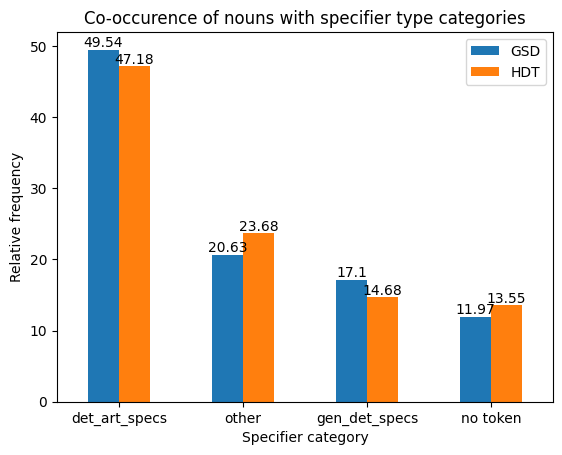

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

def quickdf(freqdict, label=''):
    return pd.DataFrame(freqdict.values(), index=freqdict.keys(), columns=[label])

def get_specs(corp):
    specs = {name: sum([val for name, val in subdict.items() if name!='non_spec'])
             for name, subdict in corp.specs.rel.items()}
    specs['no token'] = corp.specs.rel['other']['non_spec']
    specs = dict(sorted(specs.items(), key=lambda x:x[1], reverse=True))

    return specs

data = pd.concat([round(quickdf(get_specs(gsd), 'GSD').mul(100),2), 
                  round(quickdf(get_specs(hdt), 'HDT').mul(100),2)],
                 axis=1)

fig = data.plot(kind='bar', rot=0,
                title='Co-occurence of nouns with specifier type categories')

fig.set_xlabel('Specifier category')
fig.set_ylabel('Relative frequency')

for container in fig.containers:
    fig.bar_label(container)


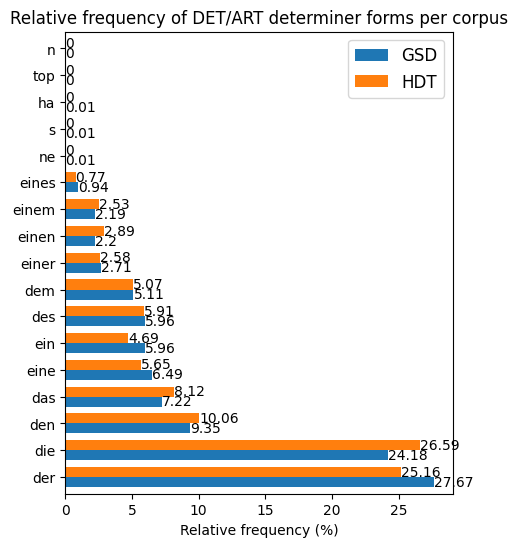

In [42]:
rel_det_freqs = pd.concat([quickdf(gsd.detarts.rel, 'GSD'),
                           quickdf(hdt.detarts.rel, 'HDT')],
                          axis=1).sort_values(by='GSD', ascending=False)
fig = rel_det_freqs.mul(100).round(2).plot(
        kind='barh', width=0.75, figsize=(5,6),
        title='Relative frequency of DET/ART determiner forms per corpus')

fig.legend(loc='upper right', prop={'size': 12})
fig.set_xlabel('Relative frequency (%)')

for container in fig.containers:
    fig.bar_label(container)


Text(0, 0.5, 'Absolute count of lemma frequency type')

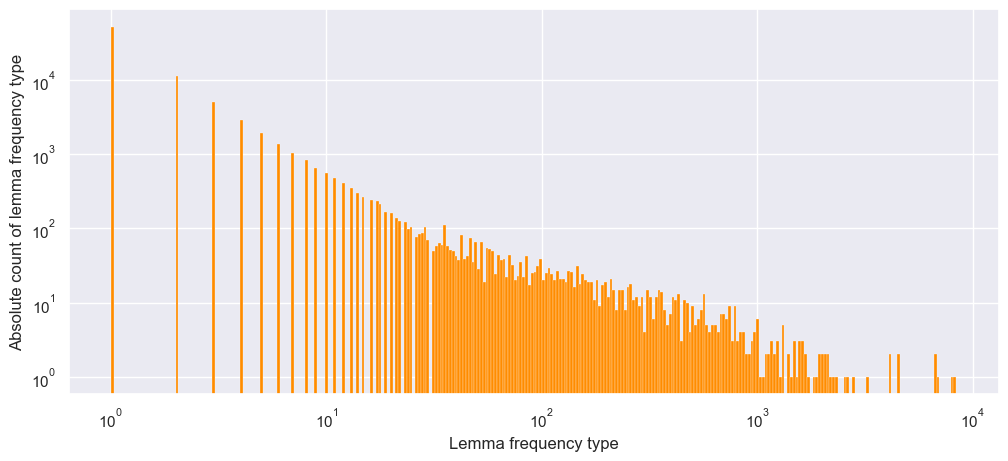

In [62]:
import seaborn as sns
sns.set_theme(rc={'figure.figsize':(12,5)})
fig = sns.histplot({x: hdt[x]._count for x in hdt.lemmas}, bins=300, alpha=1,
                   legend=False, log=True, log_scale=True, color='darkorange')
fig.set_xlabel('Lemma frequency type')
fig.set_ylabel('Absolute count of lemma frequency type')

-> More than 10,000 lemmas in HDT occured only once in the dataset.  
-> Most lemmas occured between 10 and 1,000 times.  
-> Very few lemmas occured more than 5,000 times.